# Training and Fine-Tuning BERT for Classification
## Classifying Goodreads Reviews By Book Genre

By Maria Antoniak, Melanie Walsh, and the [AI for Humanists](https://aiforhumanists.com/) Team

Updated: 2024-11-05 | **MLOps Assignment 2 — Kaggle Edition**
<br></br>

This notebook fine-tunes a RoBERTa model on Goodreads reviews from the [UCSD Book Graph](https://mengtingwan.github.io/data/goodreads.html) to predict book genre.

> **Platform:
** Run this notebook on **Kaggle** (free GPU). Go to *Settings → Accelerator → GPU T4 x2* before running.  
** Run this notebook on local-mac mps(Metal Performance shader) . Go to step3 and set the device as mps.  
** If you are not sure about the GPU  run the Step3 cell 1 to check GPU/CPU,If no gpu detected use the device as cpu.

> **Secrets:** 
Add `WANDB_API_KEY` and `HF_TOKEN` via *Add-ons → Secrets* in Kaggle — do **not** hardcode credentials.

The genres include: poetry, children, comics & graphic, fantasy & paranormal, history & biography, mystery/thriller/crime, romance, young adult.

**Pipeline steps:**
1. Install dependencies
2. Import libraries (RoBERTa + DistilBERT, W&B, sklearn, torch)
3. Load credentials from Kaggle Secrets & set config parameters
4. Download and sample Goodreads review data
5. Split data into train/test sets
6. Run TF-IDF baseline model (logistic regression)
7. Encode data for RoBERTa (tokenise, pad, label maps)
8. Build custom PyTorch dataset
9. Load pre-trained RoBERTa model
10. Configure training arguments with W&B tracking
11. Fine-tune on Kaggle GPU — metrics logged to W&B dashboard
12. Save model locally and push to Hugging Face Hub
13. Evaluate on test set — log final metrics and upload report as W&B Artifact
14. Analyse correct/incorrect predictions and plot confusion heatmaps


# Start

##  1. Installing all the requirements

In [3]:
!pip install transformers torch accelerate wandb huggingface_hub scikit-learn seaborn matplotlib gdown nbformat transformers[torch]

First, we will import necessary Python libraries and modules. These include as `gdown`, for downloading large files from Google Drive (where we will get our UCSD Goodreads reviews), as well as scikit-learn (`sklearn`) and PyTorch (`torch`), for various machine learning tools.

## 2. Import necessary Python libraries and modules**

In [4]:
# Basic Python modules
from collections import defaultdict
import random
import pickle

# For downloading large files from Google Drive
# https://github.com/wkentaro/gdown
import gdown

# For working with gzip files
# https://docs.python.org/3/library/gzip.html
import gzip

# For working with JSON files
import json

# For data manipulation and analysis
import pandas as pd
import numpy as np

# For machine learning tools and evaluation
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report,f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# For deep learning
# https://pytorch.org/tutorials/beginner/basics/quickstart_tutorial.html
import torch

# For plotting and data visualization
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import ticker
sns.set(style='ticks', font_scale=1.2)

The HuggingFace [`transformers` Python library](https://huggingface.co/transformers/installation.html) is included in Colab by default now, so we do not need to install it (but this is how you would install it with `pip`).

## 2.1 From `transformers`, we will import modules for `DistilBert`, a *distilled* or smaller version of a BERT model that runs more quickly and uses less computing power. This makes it ideal for those just getting started with BERT.

## 2.2 From `transformers`, we will import modules for `Roberta` for text sequence classifcation. This has more paramters than DistilBert.However there is a tradeoff between accracy and speed

In [5]:
from transformers import DistilBertTokenizerFast , DistilBertForSequenceClassification
from transformers import Trainer, TrainingArguments


from transformers import RobertaForSequenceClassification, RobertaTokenizer 



## 3. Set parameters and file paths and all configs

In [6]:
print(f"PyTorch: {torch.__version__} | CUDA there: {torch.cuda.is_available()}")
print(f"PyTorch: {torch.__version__} | MPS there: {torch.mps.is_available()}")
print(f"PyTorch: {torch.__version__} | CPU there: {torch.cpu.is_available()}")

PyTorch: 2.10.0+cu128 | CUDA there: True
PyTorch: 2.10.0+cu128 | MPS there: False
PyTorch: 2.10.0+cu128 | CPU there: True


In [7]:

ENABLE_WANDB = True 
ENABLE_HF   = True 


## **Step 1 — Load credentials from Kaggle Secrets**
import os
from kaggle_secrets import UserSecretsClient

secrets = UserSecretsClient()
os.environ["WANDB_API_KEY"] = secrets.get_secret("WANDB_API_KEY")
os.environ["HF_TOKEN"]      = secrets.get_secret("HF_TOKEN")

print("Secrets loaded.")




# -----

# This is the name of the BERT model that we want to use.
# We're using DistilBERT to save space (it's a distilled version of the full BERT model),
# and we're going to use the cased (vs uncased) version.

# MODEL_CLS = DistilBertForSequenceClassification
# TOKEN_CLS = DistilBertTokenizerFast
# model_name = 'distilbert-base-cased'

MODEL_CLS = RobertaForSequenceClassification
TOKEN_CLS = RobertaTokenizer
model_name = 'roberta-base'

# This is the name of the program management system for NVIDIA GPUs. We're going to send our code here.
device_name = 'cuda'
# device_name = 'mps' #Uncomment if Mac M serices GPUs
# device_name = 'cpu' #Uncomment if you don't have a GPU

# This is the maximum number of tokens in any document sent to BERT.
max_length = 512

# This is the name of the directory where we'll save our model. You can name it whatever you want.
cached_model_directory_name = f'{model_name}-reviews-genres'
HF_REPO = f"anuragvishwakarma02/{model_name}-goodreads-genres"  

Secrets loaded.



## 4 Load and sample Goodreads data

The cell below streams reviews directly from the UCSD dataset URLs.

> **If the download fails on Kaggle** (SSL / network timeout), download the `.json.gz` files manually from the links below, upload them to your Kaggle dataset, and load them with `open()` instead of `requests.get()`.  
> Manual download links: https://mengtingwan.github.io/data/goodreads.html#datasets


In [8]:
# This is where our target data is hosted on the web. You only need these paths for the book review dataset.

# Source: https://mengtingwan.github.io/data/goodreads.html#datasets

genre_url_dict = {'poetry':                 'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_poetry.json.gz',
                  'children':               'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_children.json.gz',
                  'comics_graphic':         'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_comics_graphic.json.gz',
                  'fantasy_paranormal':     'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_fantasy_paranormal.json.gz',
                  'history_biography':      'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_history_biography.json.gz',
                  'mystery_thriller_crime': 'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_mystery_thriller_crime.json.gz',
                  'romance':                'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_romance.json.gz',
                  'young_adult':            'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_young_adult.json.gz'}

Next we loop through this dictionary and use `gdown` to download the Goodreads review data for each genre from Google Drive.

Now we will load the first 100,000 reviews from each link and randomly sample 2,000 reviews.

In [9]:
import requests
# Stream reviews from URL and collect a subset
def load_reviews(url, head=10000, sample_size=2000):
    reviews = []
    count = 0

    response = requests.get(url, stream=True)
    print(response)
    with gzip.open(response.raw, 'rt', encoding='utf-8') as file:
        for line in file:
            d = json.loads(line)
            reviews.append(d['review_text'])
            count += 1

            # Stop if we have reached the 100,000 limit
            if head is not None and count >= head:
                break

    # Return random sample of reviews
    return random.sample(reviews, min(sample_size, len(reviews)))

# Reviews by genre
genre_reviews_dict = {}

# Load reviews for each genre
for genre, url in genre_url_dict.items():
    print(f'Loading reviews for genre: {genre}')
    genre_reviews_dict[genre] = load_reviews(url, head=10000, sample_size=2000)


Loading reviews for genre: poetry
<Response [200]>
Loading reviews for genre: children
<Response [200]>
Loading reviews for genre: comics_graphic
<Response [200]>
Loading reviews for genre: fantasy_paranormal
<Response [200]>
Loading reviews for genre: history_biography
<Response [200]>
Loading reviews for genre: mystery_thriller_crime
<Response [200]>
Loading reviews for genre: romance
<Response [200]>
Loading reviews for genre: young_adult
<Response [200]>


Let's preview a couple of the key-value pairs in `genre_reviews_dict`

In [10]:
for _genre, _reviews in genre_reviews_dict.items():
   print(_genre)
   print(random.sample(_reviews, 1)[0])

poetry
Via the brief introduction, Ms. Cramer describes the concept of her book as a combination of poetry and photography, "using the photograph as a trampoline" to bounce different elements off one another..."where taste and aroma become the drink". I loved this description and knew the author's words were a sign of good things to come. 
 The wide array of photographs included in this book show that Oneida Morningstar certainly has an eye for capturing compelling imagery. There is a little bit of everything - nature, pets, people, food, cityscapes and everyday objects - included within the lovely pages of "Idealism is an attractive flower". Ms. Cramer's poetry is simple, poignant and lovely. Each poem is thoughtfully combined with a photograph to create a completely unique experience for the reader. 
 As I read "Idealism is an attractive flower", I wondered what came first, the photograph or the poem. I would have loved to know more about the author and thought that a book so full of

Here we use `pickle` to save this Python dictionary to a `.pickle` file so we can easily load it later.

*The `pickle` module allows you to save and load Python objects like lists and dictionaries.*

In [11]:
pickle.dump(genre_reviews_dict, open('genre_reviews_dict.pickle', 'wb'))
# genre_reviews_dict = pickle.load(open('genre_reviews_dict.pickle', 'rb'))

In [12]:
for _genre, _reviews in genre_reviews_dict.items():
   print(_genre)
   print(random.sample(_reviews, 1)[0])

poetry
Daddy. Lady Lazarus. Edge. Her works that marked the end of her life.....but made her immortal in my eyes.
children
I did not like the book very much 
 here is why 
 (1) The first sentence in the book "Vincent van Gogh was one of the most tragic artists who ever lived." 
 How do you explain the word "tragic" to a 6 or 10 years old? and that's not a good way to introduce an artist. 
 (2) The second sentence in the book "Nothing ever seemed to go right for him and he wasn't very happy." 
 I'm not sure if those statements are accurate because many of his paintings reflect happiness! 
 (3)The way the illustrator drew the character of Van Gogh in this book made him look nothing like Van Gogh 
 (4) "Van Gogh kept using dark colors until he discovered some very colorful Japaneses artwork" 
 I'd like to read this info in another source before I believe it. 
 However I did like some things in this book... for example 
 (1) The last page inculded a list of the museums that has Van Gogh's 


## 5. Split the data into training and test sets

When training a machine learning model, it is necessary to split your training data into two parts: a "training" set and a "test" set.

We will train our BERT model on the "training" set of Goodreads reviews and then we will evaluate how well it is performing by running it on the "test" set of Goodreads reviews that the model has never seen before.

Normally, to tune the hyperparameters, you should also create a "validation" set for tuning, and only use the "test" set once, at the end of all tuning. For simplicity, in this tutorial, we will only using a training and test set.

In [13]:
train_texts = []
train_labels = []

test_texts = []
test_labels = []

for _genre, _reviews in genre_reviews_dict.items():

  _reviews = random.sample(_reviews, 1000) # Use a very small set as an example.

  for _review in _reviews[:800]:
    train_texts.append(_review)
    train_labels.append(_genre)
  for _review in _reviews[800:]:
    test_texts.append(_review)
    test_labels.append(_genre)

Show how many Goodreads reviews and labels we have in each category: 6400 training reviews, 6400 training labels (genres), 1600 test reviews, 1600 test labels (genre)

In [14]:
len(train_texts), len(train_labels), len(test_texts), len(test_labels)

(6400, 6400, 1600, 1600)

Here's an example of a training label and review:

In [15]:
train_labels[0], train_texts[0]

('poetry',
 'Kalau kami bitjara tentang kebudajaan Indonesia, kami tidak ingat kepada melap-lap hasil kebudajaan lama sampai berkilat dan untuk dibanggakan, tetapi kami memikirkan suatu penghidupan kebudajaan baru jang sehat. \n Surat Kepercayaan Gelanggang (hal. xi) \n Tiga Menguak Takdir adalah cita-cita dari ketiga penggagasnya: Chairil Anwar, Rivai Apin, dan Asrul Sani. Ide dasar atas terbitnya buku ini sudah ada di kepala mereka sejak satu setengah tahun sebelum mereka mendirikan \'Gelanggang\'. Gelanggang sendiri adalah sebuah rubrik kebudayaan yang mengisi warta mingguan \'Siasat\'. Tabloid Siasat mulanya diasuh oleh Chairil Anwar dan Ida Nasution. Kemudian, dilanjutkan oleh Rivai Apin, Asrul Sani, Siti Nuraini, dan terakhir oleh Ramadhan K.H. \n Gelanggang bisa diartikan sebagai termpat berkumpulnya sastrawan Angkatan \'45. Pada waktu itu, Chairil-Rivai-Asrul hendak menjadikan Gelanggang sebagai suatu kumpulan kesenian (Kunstkring). Tetapi, setelah melalui berbagai diskusi dan 

## 6. Run a baseline model (logistic regression)

Here we train and evaluate a simple TF-IDF baseline model using logistic regression.

We find better-than-random performance, even for a very small dataset. We'll see whether BERT can beat this good baseline!

In [16]:
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(train_texts)
X_test = vectorizer.transform(test_texts)

We train a logistic regression model from scikit-learn on the Goodreads training data, and then we use the trained model to make predictions on our Goodreads review test set.

In [17]:
model = LogisticRegression(max_iter=1000).fit(X_train, train_labels)
predictions = model.predict(X_test)

We can use scikit-learn's `classification_report` function to evaluate how well the logistic regression model's predictions match up with the true labels for the Goodreads reviews.

Importantly, we can see that our average scores are above random performance (we have 8 classes, so random performance would be ~0.2).

In [18]:
print(classification_report(test_labels, predictions))

                        precision    recall  f1-score   support

              children       0.62      0.66      0.64       200
        comics_graphic       0.82      0.73      0.77       200
    fantasy_paranormal       0.42      0.32      0.36       200
     history_biography       0.56      0.56      0.56       200
mystery_thriller_crime       0.52      0.51      0.51       200
                poetry       0.64      0.74      0.69       200
               romance       0.56      0.62      0.59       200
           young_adult       0.40      0.41      0.41       200

              accuracy                           0.57      1600
             macro avg       0.57      0.57      0.57      1600
          weighted avg       0.57      0.57      0.57      1600



## 7. **Encode data for BERT/Roberta**

We're going to transform our texts and labels into a format that BERT (via Huggingface and PyTorch) will understand. This is called *encoding* the data.

Here are the steps we need to follow:

1. The labels&mdash;in this case, Goodreads genres&mdash;need to be turned into integers rather than strings.

2. The texts&mdash;in this case, Goodreads reviews&mdash;need to be truncated if they're more than 512 tokens or padded if they're fewer than 512 tokens. The tokens, or words in the texts, also need to be separated into "word pieces" and matched to their embedding vectors.

3. We need to add special tokens to help BERT:

| BERT special token | Explanation |
| --------------| ---------|
| [CLS] | Start token of every document. |
| [SEP] | Separator between each sentence |
| [PAD] | Padding at the end of the document as many times as necessary, up to 512 tokens |
|  &#35;&#35; | Start of a "word piece" |




Here we will load `DistilBertTokenizerFast` from the HuggingFace library, which will do all the work of encoding the texts for us. The `tokenizer()` will break word tokens into word pieces, truncate to 512 tokens, and add padding and special BERT tokens.

In [19]:
tokenizer = TOKEN_CLS.from_pretrained(model_name) # The model_name needs to match our pre-trained model.

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Here we will create a map of our labels, or Goodreads genres, to integer keys. We take the unique labels, and then we make a dictionary that associates each label/tag with an integer.

**Note:** HuggingFace documentation sometimes refers to "labels" as "tags" but these are the same thing. We use "labels" throughout this notebook for clarity.

In [20]:
unique_labels = set(label for label in train_labels)
label2id = {label: id for id, label in enumerate(unique_labels)}
id2label = {id: label for label, id in label2id.items()}

In [21]:
label2id.keys()

dict_keys(['poetry', 'mystery_thriller_crime', 'romance', 'young_adult', 'fantasy_paranormal', 'history_biography', 'children', 'comics_graphic'])

In [22]:
id2label.keys()

dict_keys([0, 1, 2, 3, 4, 5, 6, 7])

Now let's encode our texts and labels!

In [23]:
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=max_length)
test_encodings  = tokenizer(test_texts, truncation=True, padding=True, max_length=max_length)

train_labels_encoded = [label2id[y] for y in train_labels]
test_labels_encoded  = [label2id[y] for y in test_labels]

**Examine a Goodreads review in the training set after encoding**

In [24]:
' '.join(train_encodings[0].tokens[0:100])

'<s> Kal au Ġk ami Ġbit j ara Ġtent ang Ġke b ud aja an ĠIndonesia , Ġk ami Ġtid ak Ġing at Ġke p ada Ġmel ap - lap Ġhas il Ġke b ud aja an Ġl ama Ġs amp ai Ġb erk il at Ġdan Ġunt uk Ġd ib ang g ak an , Ġtet api Ġk ami Ġmem ik irk an Ġsu atu Ġpen gh id up an Ġke b ud aja an Ġbar u Ġj ang Ġse hat . Ġ Ċ ĠSur at ĠKe per c aya an ĠGel ang gang Ġ( hal . Ġx i'

**Examine a Goodreads review in the test set after encoding**

In [25]:
' '.join(test_encodings[0].tokens[0:100])

'<s> Like Ġan Ġadult , Ġinappropriate Ġversion Ġof ĠShel ĠSilver stein . ĠIt Ġwas Ġsurprisingly Ġinsightful . </s> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad>'

**Examine the training labels after encoding**

In [26]:
set(train_labels_encoded)

{0, 1, 2, 3, 4, 5, 6, 7}

**Examine the test labels after encoding**

In [27]:
set(test_labels_encoded)

{0, 1, 2, 3, 4, 5, 6, 7}


## 8. **Make a custom Torch dataset**

Here we combine the encoded labels and texts into dataset objects. We use the custom Torch `MyDataSet` class to make a `train_dataset` object from  the `train_encodings` and `train_labels_encoded`. We also make a `test_dataset` object from `test_encodings`, and `test_labels_encoded`.

In [28]:
class MyDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [29]:
train_dataset = MyDataset(train_encodings, train_labels_encoded)
test_dataset = MyDataset(test_encodings, test_labels_encoded)

**Examine a Goodreads review in the Torch `training_dataset` after encoding**

In [30]:
' '.join(train_dataset.encodings[0].tokens[0:100])

'<s> Kal au Ġk ami Ġbit j ara Ġtent ang Ġke b ud aja an ĠIndonesia , Ġk ami Ġtid ak Ġing at Ġke p ada Ġmel ap - lap Ġhas il Ġke b ud aja an Ġl ama Ġs amp ai Ġb erk il at Ġdan Ġunt uk Ġd ib ang g ak an , Ġtet api Ġk ami Ġmem ik irk an Ġsu atu Ġpen gh id up an Ġke b ud aja an Ġbar u Ġj ang Ġse hat . Ġ Ċ ĠSur at ĠKe per c aya an ĠGel ang gang Ġ( hal . Ġx i'

**Examine a Goodreads review in the Torch `test_dataset` after encoding**

In [31]:
' '.join(test_dataset.encodings[1].tokens[0:100])

'<s> !! Ġw l sw f Ġ\' Z l Ġ\' H b W k ĠH t W ~ Ġy \'t y Ġz mn Ġl m Ġ Ċ Ġ: Ġml H Z @ Ġ Ċ Ġ" Ġr sw mt Ġd kh ly W @ Ġ.. ĠG yr Ġm br Wr @ Ġ" </s> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad>'


## 9. **Load pre-trained BERT/Roberta model**

Here we load a pre-trained DistilBERT model and send it to CUDA.

**Note:** If you decide to repeat fine-tuning after already running the following cells, make sure that you re-run this cell to re-load the original pre-trained model before fine-tuning again.

In [32]:
# The model_name needs to match the name used for the tokenizer above.
model = MODEL_CLS.from_pretrained(model_name, num_labels=len(id2label)).to(device_name)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


<br><br>

# 10. **Set the BERT fine-tuning parameters**

These are the arguments we'll set in the HuggingFace TrainingArguments objects, which we'll then pass to the HuggingFace Trainer object. There are many more possible arguments, but here we highlight the basics and some common gotchas.

When training your own model, you should search over these parameters to find the best settings for your particular dataset. You should use a held-out set of validation data for this step.

| Parameter | Explanation |
|-----------| ------------|
| num_train_epochs | total number of training epochs (how many times to pass through the entire dataset; too much can cause overfitting) |
| per_device_train_batch_size | batch size per device during training |
| per_device_eval_batch_size |  batch size for evaluation |
|  warmup_steps |  number of warmup steps for learning rate scheduler (set lower because of small dataset size) |
| weight_decay | strength of weight decay (reduces size of weights, like regularization) |
| output_dir | output directory for the fine-tuned model and configuration files |
| logging_dir | directory for storing logs |
| logging_steps | how often to print logging output (so that we can stop training early if the loss isn't going down) |
| evaluation_strategy | evaluate while training so that we can see the accuracy going up |

<br><br>

## 10.1 **Fine-tune the BERT model**

In [33]:
from datetime import datetime
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
print(timestamp)

training_args = TrainingArguments(
    num_train_epochs=3,
    per_device_train_batch_size=10,
    per_device_eval_batch_size=16,
    learning_rate=5e-5,
    warmup_steps=100,
    weight_decay=0.01,
    output_dir='./results',
    logging_dir='./logs',
    logging_steps=50,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    report_to=[] if not ENABLE_WANDB else ['wandb'],          # sends all metrics to W&B automatically
    run_name=f'{model_name}-run-{timestamp}',
)


`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


20260521_090344


First, we define a custom evaluation function that returns the accuracy. You could modify this function to return precision, recall, F1, and/or other metrics.

In [34]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds  = pred.predictions.argmax(-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        "precision": precision_recall_fscore_support(labels, preds, average='weighted')[0],
        "recall": precision_recall_fscore_support(labels, preds, average='weighted')[1],
        'f1':       f1_score(labels, preds, average='weighted'),
    }


Then we create a HuggingFace `Trainer` object using the `TrainingArguments` object that we created above. We also send our `compute_metrics` function to the `Trainer` object, along with our test and train datasets.

**Note:** This is what we've been aiming for this whole time! All the work of tokenizing, creating datasets, and setting the training arguments was for this cell.

In [35]:
trainer = Trainer(
    model=model,                         # the instantiated 🤗 Transformers model to be trained
    args=training_args,                  # training arguments, defined above
    train_dataset=train_dataset,         # training dataset
    eval_dataset=test_dataset,           # evaluation dataset (usually a validation set; here we just send our test set)
    compute_metrics=compute_metrics      # our custom evaluation function
)

Time to finally fine-tune!

On **Kaggle with a T4 GPU**, this should take around 5–10 minutes for 3 epochs. Training loss, validation loss, accuracy, and F1 are automatically logged to your W&B dashboard via `report_to='wandb'`.


In [36]:
# Turn off weights and biases logging, which requires an API key

import os,json,wandb
if ENABLE_WANDB:
    wandb.init(
        project='mlops-assignment2',
        name=f'{model_name}-run-1-'+timestamp,
        config={
            'model':         model_name,
            'epochs':        3,
            'batch_size':    10,
            'learning_rate': 5e-5,
            'max_length':    max_length,
            'dataset':       'UCSD Goodreads',
        },
    )
else:
    print("Weights and Biases logging is disabled. Set ENABLE_WANDB to True to enable it.")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: g25ait2017 (g25ait2017-prom-iit-rajasthan) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [37]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,2.581027,2.355291,0.577500,0.622053,0.577500,0.580868
2,1.927869,2.259915,0.604375,0.619997,0.604375,0.607584
3,1.439101,2.252217,0.631875,0.638437,0.631875,0.634463


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=960, training_loss=2.136040171980858, metrics={'train_runtime': 1138.2932, 'train_samples_per_second': 16.867, 'train_steps_per_second': 0.843, 'total_flos': 5052004407705600.0, 'train_loss': 2.136040171980858, 'epoch': 3.0})

(Optional) If you've already fine-tuned and saved the model, you can reload it using the following line. You don't have to run fine-tuning every time you want to evaluate.

In [38]:
# trainer = DistilBertForSequenceClassification.from_pretrained(cached_model_directory_name)

<br><br>

## 10.2 Save fine-tuned model and push to Hugging Face Hub**

Save the model locally, then push it and the tokenizer to your public Hugging Face profile.


In [39]:
trainer.save_model(cached_model_directory_name)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [40]:
# Push model and tokenizer to Hugging Face Hub
tokenizer = MODEL_CLS.from_pretrained(model_name)

model.push_to_hub(HF_REPO, token=os.environ["HF_TOKEN"])
tokenizer.push_to_hub(HF_REPO, token=os.environ["HF_TOKEN"])

hf_url = f"https://huggingface.co/{HF_REPO}"
print(f"Model pushed to: {hf_url}")

# Log the HF model URL into the W&B run summary
wandb.run.summary["huggingface_model"] = hf_url


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


README.md: 0.00B [00:00, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Model pushed to: https://huggingface.co/anuragvishwakarma02/roberta-base-goodreads-genres


<br><br>

## 11. **Evaluate fine-tuned model**

The following function of the `Trainer` object will run the built-in evaluation, including our `compute_metrics` function.

In [41]:
import json

eval_results = trainer.evaluate()

print(eval_results)

# Log final metrics explicitly to W&B
wandb.log({
    "final/loss" :     eval_results.get("eval_loss"),
    "final/accuracy" : eval_results.get("eval_accuracy"),
    "final/f1" :       eval_results.get("eval_f1"),
})

# Save classification report to file
preds_output  = trainer.predict(test_dataset)
preds_labels  = preds_output.predictions.argmax(-1).flatten().tolist()
preds_strings = [id2label[l] for l in preds_labels]

report_dict = classification_report(test_labels, preds_strings, output_dict=True)
report_str  = classification_report(test_labels, preds_strings)
print(report_str)

with open("eval_report.json", "w") as f:
    json.dump(report_dict, f, indent=2)

# Upload report as a versioned W&B Artifact
artifact = wandb.Artifact("eval-report", type="evaluation")
artifact.add_file("eval_report.json")
wandb.log_artifact(artifact)



/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 2.2522168159484863, 'eval_accuracy': 0.631875, 'eval_precision': 0.6384368654317685, 'eval_recall': 0.631875, 'eval_f1': 0.6344627070029427, 'eval_runtime': 27.4514, 'eval_samples_per_second': 58.285, 'eval_steps_per_second': 1.821, 'epoch': 3.0}


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


                        precision    recall  f1-score   support

              children       0.72      0.70      0.71       200
        comics_graphic       0.85      0.81      0.83       200
    fantasy_paranormal       0.44      0.48      0.46       200
     history_biography       0.67      0.58      0.63       200
mystery_thriller_crime       0.56      0.59      0.57       200
                poetry       0.80      0.78      0.79       200
               romance       0.59      0.60      0.60       200
           young_adult       0.47      0.49      0.48       200

              accuracy                           0.63      1600
             macro avg       0.64      0.63      0.63      1600
          weighted avg       0.64      0.63      0.63      1600



<Artifact eval-report>

But we might want to do more fine-grained analysis of the model, so we extract the predicted labels.

In [42]:
predicted_results = trainer.predict(test_dataset)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


In [43]:
wandb.finish()
print("W&B run finished. Artifact uploaded.")


eval/accuracy,▁▄██
eval/f1,▁▄██
eval/loss,█▂▁▁
eval/precision,▂▁██
eval/recall,▁▄██
eval/runtime,▃▁▂█
eval/samples_per_second,▆█▇▁
eval/steps_per_second,▆█▇▁
final/accuracy,▁
final/f1,▁
+14,...


W&B run finished. Artifact uploaded.


In [44]:
predicted_results.predictions.shape

(1600, 8)

In [45]:
predicted_labels = predicted_results.predictions.argmax(-1) # Get the highest probability prediction
predicted_labels = predicted_labels.flatten().tolist()      # Flatten the predictions into a 1D list
predicted_labels = [id2label[l] for l in predicted_labels]  # Convert from integers back to strings for readability

In [46]:
len(predicted_labels)

1600

In [47]:
print(classification_report(test_labels,
                            predicted_labels))

                        precision    recall  f1-score   support

              children       0.72      0.70      0.71       200
        comics_graphic       0.85      0.81      0.83       200
    fantasy_paranormal       0.44      0.48      0.46       200
     history_biography       0.67      0.58      0.63       200
mystery_thriller_crime       0.56      0.59      0.57       200
                poetry       0.80      0.78      0.79       200
               romance       0.59      0.60      0.60       200
           young_adult       0.47      0.49      0.48       200

              accuracy                           0.63      1600
             macro avg       0.64      0.63      0.63      1600
          weighted avg       0.64      0.63      0.63      1600




## 12. **Pull out correct and incorrect classifications for examination**

Let's use our predicted labels for some analysis!

Now that we've fine-tuned and pulled out our predicted labels, the BERT part of this tutorial is done. You can now use the predicted labels in the same way you would use any set of predicted labels from any classification model. We'll show some examples here.

First, let's print out some example predictions that were correct.

In [48]:
for _true_label, _predicted_label, _text in random.sample(list(zip(test_labels, predicted_labels, test_texts)), 20):
  if _true_label == _predicted_label:
    print('LABEL:', _true_label)
    print('REVIEW TEXT:', _text[:100], '...')
    print()

LABEL: romance
REVIEW TEXT: Yet another excellent installment in this series. 
 Penelope Featherington has loved Colin Bridgerto ...

LABEL: children
REVIEW TEXT: I wanted to like this book... but i found it boring and my son wasn't much interested either. Maybe  ...

LABEL: poetry
REVIEW TEXT: " syqwlwn : 
 h 'nt tTlbu th'ran yTwl 
 fkhdh -lan- m tstTy` : 
 qlylan mn lHq .. 
 fy hdhh lsnwt lq ...

LABEL: comics_graphic
REVIEW TEXT: As a person, I have my own history of violence, and that history has led me to become obsessed, as a ...

LABEL: comics_graphic
REVIEW TEXT: Gillen's Darth Vader is unfortunately a big step down from Aaron's Star Wars. 
 Part of the problem  ...

LABEL: children
REVIEW TEXT: You will need some Cheerios for this book. It's an interactive book where you place the pieces of ce ...

LABEL: romance
REVIEW TEXT: He's live! 
 FALLEN #4 - http://amzn.to/1jontbn 
 4.5 My Favorite In The Series - Stars 
 Yeah, this ...

LABEL: mystery_thriller_crime
REVIEW TEXT: I lo

Now let's print out some misclassifications.

In [49]:
for _true_label, _predicted_label, _text in random.sample(list(zip(test_labels, predicted_labels, test_texts)), 20):
  if _true_label != _predicted_label:
    print('TRUE LABEL:', _true_label)
    print('PREDICTED LABEL:', _predicted_label)
    print('REVIEW TEXT:', _text[:100], '...')
    print()

TRUE LABEL: mystery_thriller_crime
PREDICTED LABEL: fantasy_paranormal
REVIEW TEXT: Finally finished. Painfully slow. Not my style. ...

TRUE LABEL: poetry
PREDICTED LABEL: history_biography
REVIEW TEXT: I read this book thinking it would make the ultimate Mother's Day Gift. Here is a book about mothers ...

TRUE LABEL: mystery_thriller_crime
PREDICTED LABEL: romance
REVIEW TEXT: I LOVED this book. I've enjoyed everything of LL's that I have read, but this one was special. Creep ...

TRUE LABEL: young_adult
PREDICTED LABEL: fantasy_paranormal
REVIEW TEXT: I was given this book as a gift for an honest review. I do not usually like biblical type books or a ...

TRUE LABEL: young_adult
PREDICTED LABEL: children
REVIEW TEXT: I have watched Disney's Mulan for over a hundred times and the non Disney Mulan by more than a coupl ...

TRUE LABEL: young_adult
PREDICTED LABEL: fantasy_paranormal
REVIEW TEXT: I've read this series over ten years ago. But I remember it being very good. For the first

Finally, let's create some heatmaps to examine misclassification patterns. We could use these patterns to think about similarities and differences between genres, according to book reviewers.

In [50]:
genre_classifications_dict = defaultdict(int)
for _true_label, _predicted_label in zip(test_labels, predicted_labels):
  genre_classifications_dict[(_true_label, _predicted_label)] += 1

dicts_to_plot = []
for (_true_genre, _predicted_genre), _count in genre_classifications_dict.items():
  dicts_to_plot.append({'True Genre': _true_genre,
                        'Predicted Genre': _predicted_genre,
                        'Number of Classifications': _count})

df_to_plot = pd.DataFrame(dicts_to_plot)
df_wide = df_to_plot.pivot_table(index='True Genre',
                                 columns='Predicted Genre',
                                 values='Number of Classifications')

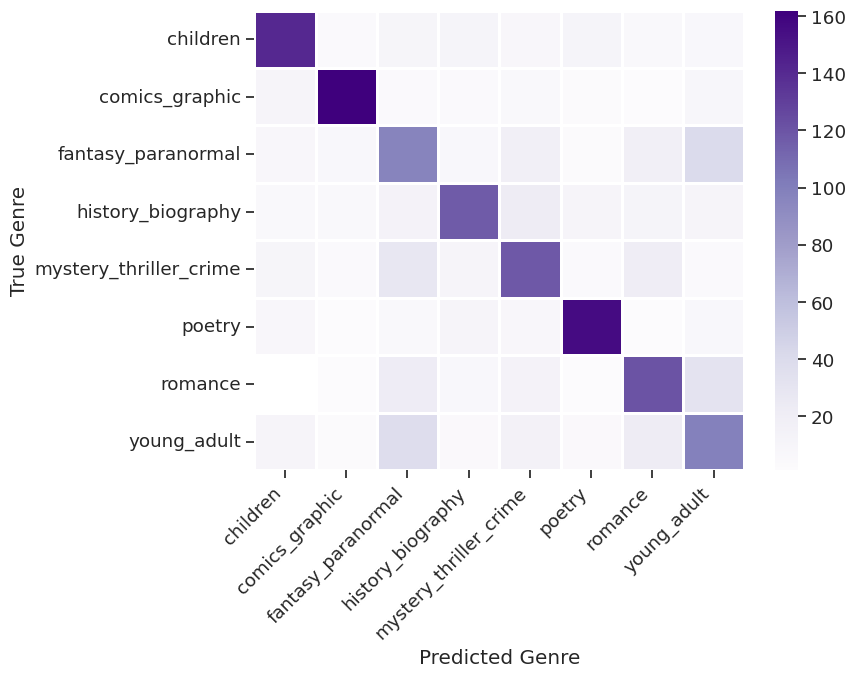

In [51]:
plt.figure(figsize=(9,7))
sns.set(style='ticks', font_scale=1.2)
sns.heatmap(df_wide, linewidths=1, cmap='Purples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Looks good! We can see that overall, our model is assigning the correct labels for each genre.

Now, let's remove the diagonal from the plot to highlight the misclassifications.

In [52]:
genre_classifications_dict = defaultdict(int)
for _true_label, _predicted_label in zip(test_labels, predicted_labels):
  if _true_label != _predicted_label: # Remove the diagonal to highlight misclassifications
    genre_classifications_dict[(_true_label, _predicted_label)] += 1

dicts_to_plot = []
for (_true_genre, _predicted_genre), _count in genre_classifications_dict.items():
  dicts_to_plot.append({'True Genre': _true_genre,
                        'Predicted Genre': _predicted_genre,
                        'Number of Classifications': _count})

df_to_plot = pd.DataFrame(dicts_to_plot)
df_wide = df_to_plot.pivot_table(index='True Genre',
                                 columns='Predicted Genre',
                                 values='Number of Classifications')

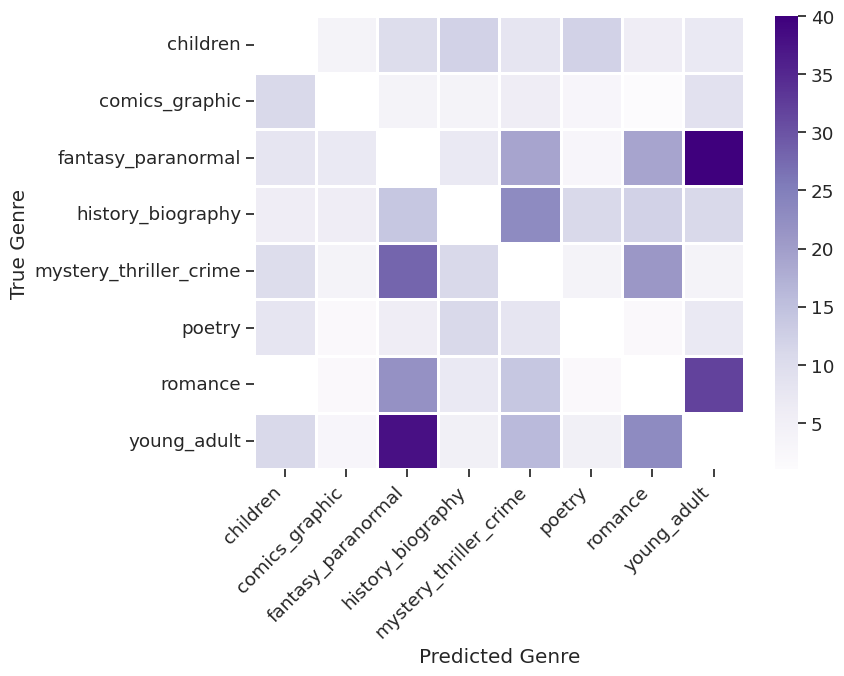

In [53]:
plt.figure(figsize=(9,7))
sns.set(style='ticks', font_scale=1.2)
sns.heatmap(df_wide, linewidths=1, cmap='Purples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

There's much more you can do with your own dataset and labels! Classification can be used to apply a small set of labels across a big dataset; to explore misclassifications to better understand users; and much more! We hope you'll use this tutorial in all kinds of creative ways.